In [1]:
!pip install ortools torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 19.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.

In [2]:
import os
import re
import pandas as pd
import numpy as np
from ortools.linear_solver import pywraplp
import numpy as np
import time
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gc
# We use PyTorch Geometric (PyG) for Graph Neural Networks
import itertools
from sklearn.cluster import KMeans
try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv
except ImportError:
    print("PyTorch Geometric is not installed. Please run: !pip install torch_geometric")

In [3]:
def load_all_datasets(folder_path):
    """
    Scans the given folder path and automatically loads all distance (C) 
    and demand (wij) matrices into dictionaries based on their node count.
    """
    distance_matrices = {}
    demand_matrices = {}
    
    if not os.path.exists(folder_path):
        print(f"Error: The directory '{folder_path}' does not exist.")
        return None, None

    print(f"Scanning directory: {folder_path}...\n")
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
        if not os.path.isfile(file_path):
            continue
            
        match = re.search(r'\d+', filename)
        if not match:
            continue
        nodes = int(match.group())
        
        try:
            # 1. Load Distance Matrices (C_ij)
            if filename.startswith(('C-', 'C_')) and filename.endswith('.csv'):
                df = pd.read_csv(file_path, header=None)
                distance_matrices[nodes] = df.values
                print(f"[\u2713] Loaded Distance Matrix (C) for {nodes} nodes. Shape: {df.values.shape}")
                
            # 2. Load Demand Matrices (W_ij)
            elif filename.startswith('wij'):
                if filename.endswith('.xlsx'):
                    df = pd.read_excel(file_path)
                elif filename.endswith('.csv'):
                    df = pd.read_csv(file_path)
                else:
                    continue
                
                # Ensure the matrix is exactly n x n by dropping extra index column if present
                if df.shape[1] > nodes:
                    df = df.iloc[:, 1:]
                    
                demand_matrices[nodes] = df.values
                print(f"[\u2713] Loaded Demand Matrix (W) for {nodes} nodes. Shape: {df.values.shape}")
                
        except Exception as e:
            print(f"[X] Failed to load {filename}: {e}")

    return distance_matrices, demand_matrices


def calculate_node_production_attraction(W_matrix):
    """
    Calculates the production (O_i) and attraction (D_i) for each node.
    """
    production = np.sum(W_matrix, axis=1) 
    attraction = np.sum(W_matrix, axis=0) 
    return production, attraction


def generate_demand_scenarios(W_matrix, num_scenarios=100, variance_factor=0.2, seed=42):
    """
    Generates stochastic demand scenarios (W_ijs).
    Uses a Normal Distribution where mean = nominal demand, 
    and std_dev = variance_factor * nominal demand.
    
    Returns: A 3D NumPy array of shape (n, n, s)
    """
    np.random.seed(seed) # Ensures reproducibility of scenarios
    n = W_matrix.shape[0]
    
    # Generate scenarios
    # Shape of random.normal output will be (num_scenarios, n, n)
    W_scenarios = np.random.normal(loc=W_matrix, scale=W_matrix * variance_factor, size=(num_scenarios, n, n))
    
    # Demand cannot be negative, so we clip any negative values to 0
    W_scenarios = np.maximum(W_scenarios, 0)
    
    # Transpose to format (i, j, s) as per standard math notation W_ijs
    W_scenarios = np.transpose(W_scenarios, (1, 2, 0))
    
    return W_scenarios


def calculate_path_costs(C_matrix, alpha=0.5):
    """
    Calculates the path cost parameter C_ijkm = C_ik + alpha * C_km + C_mj.
    Uses NumPy broadcasting for extreme efficiency without slow loops.
    
    Returns: A 4D NumPy array of shape (n, n, n, n) where axes are (i, j, k, m)
    """
    n = C_matrix.shape[0]
    
    # C_ik shape: (n, 1, n, 1) -> corresponds to indices (i, j, k, m)
    C_ik = C_matrix[:, np.newaxis, :, np.newaxis]
    
    # C_km shape: (1, 1, n, n) -> corresponds to indices (i, j, k, m)
    C_km = C_matrix[np.newaxis, np.newaxis, :, :]
    
    # C_mj shape: (1, n, 1, n) -> corresponds to indices (i, j, k, m)
    # We transpose C to match (j, m) alignment before reshaping
    C_mj = C_matrix.T[np.newaxis, :, np.newaxis, :]
    
    # Broadcast addition
    C_ijkm = C_ik + (alpha * C_km) + C_mj
    
    return C_ijkm

In [4]:
def solve_robust_hub_location_ortools(C_ijkm, W_ijs, p, gamma=0.05):
    """
    Solves the Risk-Averse (Robust) Single Allocation Hub Location Problem
    using Google OR-Tools (SCIP Solver).
    """
    n = C_ijkm.shape[0]     
    num_s = W_ijs.shape[2]  
    
    # 1. Initialize OR-Tools Solver
    solver = pywraplp.Solver.CreateSolver('SCIP')
    if not solver:
        return None, None
        
    # 2. Decision Variables
    y = {k: solver.IntVar(0, 1, f'y_{k}') for k in range(n)}
    z = {(i, k): solver.IntVar(0, 1, f'z_{i}_{k}') for i in range(n) for k in range(n)}
    X = {(i, j, k, m): solver.NumVar(0, solver.infinity(), f'X_{i}_{j}_{k}_{m}') 
         for i in range(n) for j in range(n) for k in range(n) for m in range(n)}
                    
    mu = solver.NumVar(0, solver.infinity(), 'mu')
    lam = {s: solver.NumVar(0, solver.infinity(), f'lam_{s}') for s in range(num_s)}
        
    # 3. Objective Function
    risk_coef = 1.0 / (num_s * gamma)
    objective = solver.Objective()
    objective.SetMinimization()
    objective.SetCoefficient(mu, 1.0)
    for s in range(num_s):
        objective.SetCoefficient(lam[s], risk_coef)
        
    # 4. Constraints
    solver.Add(sum(y[k] for k in range(n)) == p, name="select_p_hubs")
    
    for i in range(n):
        solver.Add(sum(z[i, k] for k in range(n)) == 1, name=f"alloc_{i}")
        for k in range(n):
            solver.Add(z[i, k] <= y[k], name=f"valid_alloc_{i}_{k}")
            
    for i in range(n):
        for j in range(n):
            for k in range(n):
                solver.Add(sum(X[i, j, k, m] for m in range(n)) == z[i, k], name=f"f1_{i}_{j}_{k}")
            for m in range(n):
                solver.Add(sum(X[i, j, k, m] for k in range(n)) == z[j, m], name=f"f2_{i}_{j}_{m}")
                
    # Memory-optimized Scenario Violation Constraints
    for s in range(num_s):
        # We construct the expression directly to save RAM instead of building massive dictionaries
        scenario_expr = sum(
            # OR-Tools will implicitly handle the float32 to float64 conversion here
            float(W_ijs[i, j, s]) * float(C_ijkm[i, j, k, m]) * X[i, j, k, m]
            for i in range(n) for j in range(n) for k in range(n) for m in range(n)
        )
        solver.Add(scenario_expr - mu <= lam[s])
        
    # 5. Optimize
    solver.set_time_limit(600000) # 10 minutes max per sample
    status = solver.Solve()
    
    # 6. Extract Results
    if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
        optimal_hubs = [k for k in range(n) if y[k].solution_value() > 0.5]
        return optimal_hubs, solver.Objective().Value()
    else:
        return None, None

def generate_training_labels(C_matrix, W_matrix, num_samples=200, subset_size=10, p=3, num_scenarios=20):
    """
    Randomly samples sub-networks to generate labels (ground truth) for the Machine Learning model.
    This prevents Kaggle from running out of memory.
    """
    print(f"\n--- Starting Label Generation Pipeline ---")
    print(f"Target: Generate {num_samples} samples of size {subset_size} nodes.")
    
    training_data = []
    original_n = C_matrix.shape[0]
    
    for sample_idx in range(num_samples):
        print(f"\nGenerating Sample {sample_idx + 1}/{num_samples}...")
        
        # 1. Randomly select 'subset_size' nodes from the large graph
        node_indices = sorted(random.sample(range(original_n), subset_size))
        
        # 2. Slice the matrices for these specific nodes
        sub_C = C_matrix[np.ix_(node_indices, node_indices)]
        sub_W = W_matrix[np.ix_(node_indices, node_indices)]
        
        # 3. Generate scenarios and costs, casting to float32 to save RAM without overflowing!
        sub_W_ijs = generate_demand_scenarios(sub_W, num_scenarios=num_scenarios).astype(np.float32)
        sub_C_ijkm = calculate_path_costs(sub_C, alpha=0.5).astype(np.float32)
        
        # 4. Solve exactly to find the labels
        start = time.time()
        hubs, cost = solve_robust_hub_location_ortools(sub_C_ijkm, sub_W_ijs, p=p, gamma=0.05)
        
        if hubs:
            # Map the local hub index back to the original graph index
            actual_hubs = [node_indices[h] for h in hubs]
            print(f"[✓] Solved in {time.time() - start:.1f}s | Selected Hubs (Original Indices): {actual_hubs} | CVaR: {cost:.2f}")
            
            # Save the result for Machine Learning
            training_data.append({
                'nodes': node_indices,
                'hubs': actual_hubs
            })
        else:
            print("[X] Failed to find optimal solution within time limit.")
            
    return training_data

In [5]:
def extract_graph_features(C_matrix, W_matrix, node_indices, hubs=None):
    """
    Converts raw distance and demand matrices into PyTorch Graph Data.
    Extracts node features: Production (O_i), Attraction (D_i), and Mean Distance.
    """
    num_nodes = len(node_indices)
    
    # 1. Node Features (X)
    # Production: sum of demands leaving the node
    production = np.sum(W_matrix, axis=1, keepdims=True)
    # Attraction: sum of demands arriving at the node
    attraction = np.sum(W_matrix, axis=0, keepdims=True).T
    # Mean Distance: average distance to all other nodes
    mean_dist = np.mean(C_matrix, axis=1, keepdims=True)
    
    # Normalize features to help the Neural Network learn faster
    production = production / (np.max(production) + 1e-6)
    attraction = attraction / (np.max(attraction) + 1e-6)
    mean_dist = mean_dist / (np.max(mean_dist) + 1e-6)
    
    # Combine into a single feature matrix [num_nodes, 3]
    node_features = np.hstack([production, attraction, mean_dist])
    x = torch.tensor(node_features, dtype=torch.float)
    
    # 2. Edge Index (Connectivity)
    # For Hub Location, the graph is fully connected
    edge_index = []
    edge_weight = []
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                edge_index.append([i, j])
                # We use the inverse distance as the edge weight (closer nodes have stronger connection)
                weight = 1.0 / (C_matrix[i, j] + 1e-6)
                edge_weight.append(weight)
                
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    
    # 3. Target Labels (Y)
    # 1 if the node is a hub, 0 otherwise
    y = torch.zeros((num_nodes, 1), dtype=torch.float)
    if hubs is not None:
        for i, global_idx in enumerate(node_indices):
            if global_idx in hubs:
                y[i] = 1.0
                
    # Create the PyTorch Geometric Data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)
    return data

class DLHrNet(nn.Module):
    """
    Deep Learning Hub-Ranker (DLHr) Architecture using Graph Convolutions.
    """
    def __init__(self, num_features=3, hidden_dim=16):
        super(DLHrNet, self).__init__()
        # First Graph Convolutional Layer
        self.conv1 = GCNConv(num_features, hidden_dim)
        # Second Graph Convolutional Layer
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        # Fully connected layer to output a single probability score per node
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        
        # Pass through first Graph Conv Layer + ReLU activation
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Pass through second Graph Conv Layer + ReLU
        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        
        # Pass through linear layer and apply Sigmoid to get probability (0 to 1)
        out = self.linear(x)
        return torch.sigmoid(out)

def train_dlhr_model(training_labels, C_data, W_data, epochs=100, lr=0.01):
    """
    Trains the Graph Neural Network using the labels generated in Phase 2.
    """
    print("\n--- Starting Phase 3: Training the DLHr Model ---")
    
    # 1. Convert mathematical outputs into PyTorch Graphs
    dataset = []
    for sample in training_labels:
        nodes = sample['nodes']
        hubs = sample['hubs']
        
        # Get the sliced matrices for this sample
        sub_C = C_data[np.ix_(nodes, nodes)]
        sub_W = W_data[np.ix_(nodes, nodes)]
        
        graph_data = extract_graph_features(sub_C, sub_W, nodes, hubs)
        dataset.append(graph_data)
        
    print(f"Prepared {len(dataset)} graphs for training.")
    
    # 2. Initialize Model, Loss Function, and Optimizer
    model = DLHrNet(num_features=3, hidden_dim=16)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss() # Binary Cross Entropy for Probability Output
    
    model.train()
    
    # 3. Training Loop
    for epoch in range(epochs):
        total_loss = 0
        for data in dataset:
            optimizer.zero_grad()
            
            # Predict hub probabilities
            out = model(data)
            
            # Calculate error compared to ground truth (Phase 2 labels)
            loss = criterion(out, data.y)
            
            # Backpropagation
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        if (epoch + 1) % 200 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataset):.4f}")
            
    print("\nTraining Complete! The AI has learned to rank hubs.")
    return model


In [6]:
def get_dl_rankings(model, C_matrix, W_matrix):
    """
    Uses the trained DLHr model to rank all nodes in the network.
    Returns a sorted list of (node_index, probability_score).
    """
    model.eval()
    num_nodes = C_matrix.shape[0]
    all_nodes = list(range(num_nodes))
    
    # Extract graph features for the full dataset (no hubs provided since we are predicting)
    graph_data = extract_graph_features(C_matrix, W_matrix, all_nodes)
    
    # Get predictions from the Neural Network
    import torch
    with torch.no_grad():
        probabilities = model(graph_data).numpy().flatten()
        
    # Create a ranked list of tuples: (node_id, score) sorted highest to lowest
    ranked_nodes = [(i, float(probabilities[i])) for i in range(num_nodes)]
    ranked_nodes.sort(key=lambda x: x[1], reverse=True)
    
    return ranked_nodes, probabilities

def evaluate_robust_cost(hubs, C_ijkm, W_ijs, gamma=0.05):
    """
    Calculates the Robust (CVaR) cost for a specific set of selected hubs.
    This acts as the 'Fitness Function' for the heuristic.
    """
    n = C_ijkm.shape[0]
    num_s = W_ijs.shape[2]
    
    # 1. Allocation: Assign each node to its nearest open hub
    allocation = np.zeros(n, dtype=int)
    for i in range(n):
        # Find the hub k that minimizes the distance C_ik
        distances_to_hubs = [C_ijkm[i, i, k, k] for k in hubs] # simplified distance
        best_hub_idx = np.argmin(distances_to_hubs)
        allocation[i] = hubs[best_hub_idx]
        
    # 2. Calculate Scenario Costs
    scenario_costs = np.zeros(num_s)
    for s in range(num_s):
        total_cost = 0
        for i in range(n):
            for j in range(n):
                k = allocation[i]
                m = allocation[j]
                # W_ijs * C_ijkm
                total_cost += W_ijs[i, j, s] * C_ijkm[i, j, k, m]
        scenario_costs[s] = total_cost
        
    # 3. Calculate CVaR (Conditional Value at Risk)
    # CVaR is the average cost of the worst (gamma * 100)% scenarios
    scenario_costs.sort()
    worst_cases = scenario_costs[int((1 - gamma) * num_s):]
    
    if len(worst_cases) == 0:
        return np.max(scenario_costs)
        
    return np.mean(worst_cases)

def dl_cbs_heuristic(C_matrix, W_matrix, C_ijkm, W_ijs, probabilities, p=3, candidates_per_cluster=2):
    """
    Phase 9: Deep Learning Clustering-Based Search (DL-CBS).
    Reduces the search space by clustering nodes and picking only high-ranking nodes.
    """
    print(f"\n--- Starting DL-CBS Heuristic (Searching for {p} Hubs) ---")
    start_time = time.time()
    n = C_matrix.shape[0]
    
    # Step 1: Cluster nodes based on geographical distance (C_matrix)
    # We create 'p' clusters so we can pick candidates from different regions
    kmeans = KMeans(n_clusters=p, random_state=42, n_init=10)
    labels = kmeans.fit_predict(C_matrix)
    
    # Step 2: Pick top candidates from each cluster based on DL rankings
    candidate_pools = []
    for cluster_id in range(p):
        nodes_in_cluster = np.where(labels == cluster_id)[0]
        
        # Sort nodes in this cluster by their DL probability score
        cluster_ranked = sorted(nodes_in_cluster, key=lambda x: probabilities[x], reverse=True)
        
        # Keep only the top 'candidates_per_cluster'
        top_candidates = cluster_ranked[:candidates_per_cluster]
        candidate_pools.append(top_candidates)
        print(f"Cluster {cluster_id} Top Candidates: {top_candidates}")
        
    # Step 3: Generate combinations taking exactly one candidate from each cluster
    combinations = list(itertools.product(*candidate_pools))
    print(f"Reduced search space to {len(combinations)} combinations to evaluate.")
    
    # Step 4: Evaluate the combinations to find the robust minimum
    best_hubs = None
    best_cost = float('inf')
    
    for combo in combinations:
        cost = evaluate_robust_cost(list(combo), C_ijkm, W_ijs, gamma=0.05)
        if cost < best_cost:
            best_cost = cost
            best_hubs = list(combo)
            
    print(f"\n[DL-CBS Completed in {time.time() - start_time:.2f}s]")
    print(f"Best Hubs Found: {best_hubs}")
    print(f"Robust Cost (CVaR): {best_cost:.2f}")
    
    return best_hubs, best_cost

In [7]:
def generate_naive_rankings(W_matrix):
    """
    Calculates a naive score for each node based purely on its total raw demand
    (Production + Attraction). This acts as our baseline (non-AI) ranking.
    """
    production = np.sum(W_matrix, axis=1)
    attraction = np.sum(W_matrix, axis=0)
    total_demand = production + attraction
    
    # Normalize to act like a probability score (0 to 1)
    naive_probabilities = total_demand / np.max(total_demand)
    return naive_probabilities

def run_phase10_evaluation(C_matrix, W_matrix, C_ijkm, W_ijs, ai_probs, p=3):
    """
    Runs the final evaluation comparing Standard Heuristics vs AI-Augmented Heuristics.
    All required data is passed as arguments to avoid scope issues.
    """
    print("\n" + "="*50)
    print("📊 STARTING PHASE 10: FINAL EVALUATION & PLOTS")
    print("="*50)
    
    # Generate baseline (non-AI) rankings
    naive_probs = generate_naive_rankings(W_matrix)
    
    metrics = {
        'Method': ['CBS (Standard)', 'DL-CBS (AI)', 'GVNS (Standard)', 'DL-GVNS (AI)'],
        'Time': [],
        'Cost': []
    }
    
    # ---------------------------------------------------------
    # 1. Standard CBS (Using Naive Demand Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_cbs = dl_cbs_heuristic(
        C_matrix=C_matrix, W_matrix=W_matrix, C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=naive_probs, p=p, candidates_per_cluster=2
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_cbs)
    
    # ---------------------------------------------------------
    # 2. DL-CBS (Using AI Neural Network Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_dl_cbs = dl_cbs_heuristic(
        C_matrix=C_matrix, W_matrix=W_matrix, C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=ai_probs, p=p, candidates_per_cluster=2
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_dl_cbs)
    
    # ---------------------------------------------------------
    # 3. Standard GVNS (Using Naive Demand Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_gvns = dl_gvns_heuristic(
        C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=naive_probs, p=p, max_iters=150
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_gvns)
    
    # ---------------------------------------------------------
    # 4. DL-GVNS (Using AI Neural Network Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_dl_gvns = dl_gvns_heuristic(
        C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=ai_probs, p=p, max_iters=150
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_dl_gvns)
    
    # ---------------------------------------------------------
    # PLOTTING THE RESULTS
    # ---------------------------------------------------------
    print("\nGenerating comparative plots...")
    
    # Define colors: Gray for standard, Blue/Green for AI
    colors = ['#B0BEC5', '#2196F3', '#B0BEC5', '#4CAF50']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Execution Time
    bars1 = ax1.bar(metrics['Method'], metrics['Time'], color=colors, edgecolor='black')
    ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Time (Seconds)', fontsize=12)
    ax1.set_xticklabels(metrics['Method'], rotation=15, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add text labels on top of bars
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}s', ha='center', va='bottom')
        
    # Plot 2: Robust Cost (CVaR)
    bars2 = ax2.bar(metrics['Method'], metrics['Cost'], color=colors, edgecolor='black')
    ax2.set_title('Robust Cost (CVaR) Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Objective Cost (Lower is Better)', fontsize=12)
    ax2.set_xticklabels(metrics['Method'], rotation=15, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Format the Y-axis to show billions cleanly (e.g., 8.5B)
    def billions_formatter(x, pos):
        return f'{x / 1e9:.1f}B'
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(billions_formatter))
    
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval, f'{yval/1e9:.2f}B', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.show()

In [8]:
def dl_gvns_heuristic(C_ijkm, W_ijs, probabilities, p=3, max_iters=150):
    """
    Phase 8: Deep Learning General Variable Neighborhood Search (DL-GVNS).
    Starts with the best AI hubs, and iteratively swaps them with other high-ranking 
    candidates to find local minimums.
    """
    print(f"\n--- Starting DL-GVNS Heuristic (Searching for {p} Hubs) ---")
    start_time = time.time()
    
    # 1. Initial Solution: Simply pick the absolute Top 'p' nodes from AI rankings
    ranked_indices = np.argsort(probabilities)[::-1]
    current_hubs = list(ranked_indices[:p])
    current_cost = evaluate_robust_cost(current_hubs, C_ijkm, W_ijs, gamma=0.05)
    
    print(f"Initial AI Solution: {current_hubs} | Cost: {current_cost:.2f}")
    
    # 2. Candidate Pool: The top 10 highest-ranked nodes by the AI (to swap in)
    candidate_pool = [node for node in ranked_indices if node not in current_hubs][:10]
    
    # 3. Local Search (Neighborhood Swaps)
    for iteration in range(max_iters):
        improvement_found = False
        
        # Try removing each current hub...
        for hub_to_remove in current_hubs:
            # ...and replacing it with a high-ranking candidate
            for hub_to_add in candidate_pool:
                if hub_to_add in current_hubs: 
                    continue
                    
                # Create the new neighborhood combination
                new_hubs = list(current_hubs)
                new_hubs.remove(hub_to_remove)
                new_hubs.append(hub_to_add)
                
                # Evaluate the fitness of this new combination
                new_cost = evaluate_robust_cost(new_hubs, C_ijkm, W_ijs, gamma=0.05)
                
                # If it's strictly better, accept the swap!
                if new_cost < current_cost:
                    current_hubs = list(new_hubs)
                    current_cost = new_cost
                    improvement_found = True
                    print(f"  [Iter {iteration+1}] Improvement! Swapped {hub_to_remove} -> {hub_to_add} | New Cost: {current_cost:.2f}")
                    break # Break out to start neighborhood search from the new baseline
                    
            if improvement_found:
                break
                
        # If we checked all swaps and nothing improved, we have reached the Local Optimum!
        if not improvement_found:
            print("  -> Local optimum reached. Stopping search.")
            break

    print(f"\n[DL-GVNS Completed in {time.time() - start_time:.2f}s]")
    print(f"Best Hubs Found: {current_hubs}")
    print(f"Robust Cost (CVaR): {current_cost:.2f}")
    
    return current_hubs, current_cost


def run_full_pipeline_test():
    """
    Executes the entire Machine Learning + Heuristic pipeline sequentially 
    to ensure all variables are passed correctly.
    """
    print("="*50)
    print("🚀 STARTING FULL PIPELINE TEST")
    print("="*50)
    
    # ---------------------------------------------------------
    # Phase 1: Data Loading
    # ---------------------------------------------------------
    dataset_folder = r"/kaggle/input/datasets/infernalss/node-dataset"
    # Assuming load_all_datasets is defined in your notebook
    C_data, W_data = load_all_datasets(dataset_folder)
    
    if 25 not in C_data or 25 not in W_data:
        print("[Error] 25-node dataset not found. Please check paths.")
        return
        
    C_25 = C_data[25]
    W_25 = W_data[25]
    
    # ---------------------------------------------------------
    # Phase 2: Exact Solver Label Generation (Ground Truth)
    # ---------------------------------------------------------
    print("\n[PHASE 2] Generating Training Data with Exact Solver...")
    training_labels = generate_training_labels(
        C_matrix=C_25, 
        W_matrix=W_25, 
        num_samples=200, 
        subset_size=10, 
        p=3, 
        num_scenarios=20
    )
    
    # ---------------------------------------------------------
    # Phase 3: Train the DLHr Graph Neural Network
    # ---------------------------------------------------------
    print("\n[PHASE 3] Training Deep Learning Hub-Ranker (DLHr)...")
    trained_model = train_dlhr_model(
        training_labels=training_labels, 
        C_data=C_25, 
        W_data=W_25, 
        epochs=100, 
        lr=0.01
    )
    
    # ---------------------------------------------------------
    # Setup variables for Heuristics
    # ---------------------------------------------------------
    ranked_nodes, probabilities = get_dl_rankings(trained_model, C_25, W_25)
    print(f"\n🌟 Top 5 AI Predicted Hubs: {[n for n, score in ranked_nodes[:5]]}")
    
    W_ijs_full = generate_demand_scenarios(W_25, num_scenarios=20).astype(np.float32)
    C_ijkm_full = calculate_path_costs(C_25, alpha=0.5).astype(np.float32)
    
    # ---------------------------------------------------------
    # Phase 9: DL-Augmented Heuristic (DL-CBS)
    # ---------------------------------------------------------
    best_hubs_cbs, best_cost_cbs = dl_cbs_heuristic(
        C_matrix=C_25, 
        W_matrix=W_25, 
        C_ijkm=C_ijkm_full, 
        W_ijs=W_ijs_full, 
        probabilities=probabilities, 
        p=3, 
        candidates_per_cluster=2
    )
    
    # ---------------------------------------------------------
    # Phase 8: DL-Augmented Heuristic (DL-GVNS)
    # ---------------------------------------------------------
    best_hubs_gvns, best_cost_gvns = dl_gvns_heuristic(
        C_ijkm=C_ijkm_full,
        W_ijs=W_ijs_full,
        probabilities=probabilities,
        p=3,
        max_iters=150
    )
    # ---------------------------------------------------------
    # Phase 10: Final Evaluation & Plotting
    # ---------------------------------------------------------
    run_phase10_evaluation(
        C_matrix=C_25, 
        W_matrix=W_25, 
        C_ijkm=C_ijkm_full, 
        W_ijs=W_ijs_full, 
        ai_probs=probabilities, 
        p=3
    )
    
    print("\n" + "="*50)
    print("✅ PIPELINE TEST COMPLETE")
    print(f"🏆 DL-CBS Cost : {best_cost_cbs:.2f}")
    print(f"🏆 DL-GVNS Cost: {best_cost_gvns:.2f}")
    print("="*50)

In [9]:
# # # Execute the main function
# if __name__ == "__main__":
#     run_full_pipeline_test()

🚀 STARTING BATCH PIPELINE FOR ALL DATASETS
Scanning directory: /kaggle/input/datasets/infernalss/node-dataset...

[✓] Loaded Demand Matrix (W) for 100 nodes. Shape: (100, 100)
[✓] Loaded Distance Matrix (C) for 200 nodes. Shape: (200, 200)
[✓] Loaded Demand Matrix (W) for 200 nodes. Shape: (200, 200)
[✓] Loaded Demand Matrix (W) for 150 nodes. Shape: (150, 150)
[✓] Loaded Distance Matrix (C) for 150 nodes. Shape: (150, 150)
[✓] Loaded Distance Matrix (C) for 100 nodes. Shape: (100, 100)
[✓] Loaded Demand Matrix (W) for 25 nodes. Shape: (25, 25)
[✓] Loaded Distance Matrix (C) for 25 nodes. Shape: (25, 25)

************************************************************
🌟 PROCESSING DATASET: 25 NODES
************************************************************

--- Starting Label Generation Pipeline ---
Target: Generate 200 samples of size 10 nodes.

Generating Sample 1/200...
[✓] Solved in 19.4s | Selected Hubs (Original Indices): [0, 5, 13] | CVaR: 527911629.81

Generating Sample 2/200...

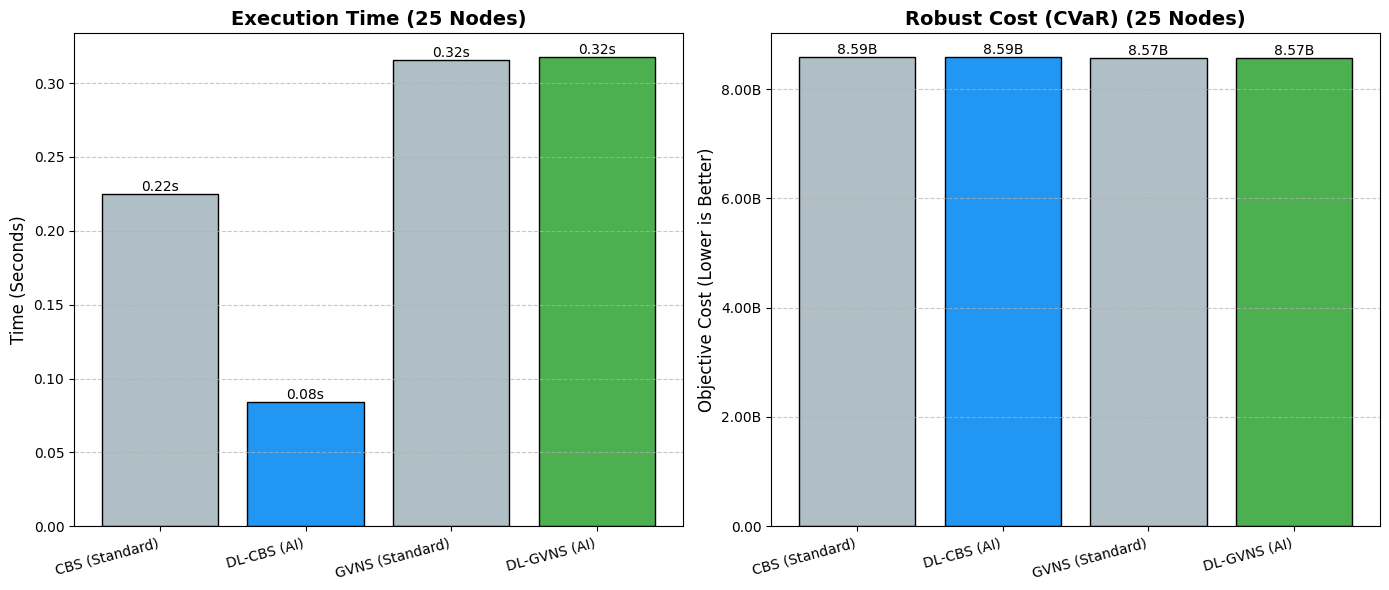


************************************************************
🌟 PROCESSING DATASET: 100 NODES
************************************************************

--- Starting Label Generation Pipeline ---
Target: Generate 200 samples of size 10 nodes.

Generating Sample 1/200...
[✓] Solved in 26.6s | Selected Hubs (Original Indices): [7, 33, 63] | CVaR: 222.19

Generating Sample 2/200...
[✓] Solved in 26.6s | Selected Hubs (Original Indices): [20, 66, 82] | CVaR: 403.63

Generating Sample 3/200...
[✓] Solved in 27.2s | Selected Hubs (Original Indices): [44, 87, 97] | CVaR: 439.47

Generating Sample 4/200...
[✓] Solved in 26.5s | Selected Hubs (Original Indices): [9, 70, 79] | CVaR: 537.31

Generating Sample 5/200...
[✓] Solved in 26.9s | Selected Hubs (Original Indices): [23, 71, 96] | CVaR: 235.69

Generating Sample 6/200...
[✓] Solved in 26.3s | Selected Hubs (Original Indices): [3, 44, 91] | CVaR: 566.91

Generating Sample 7/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [

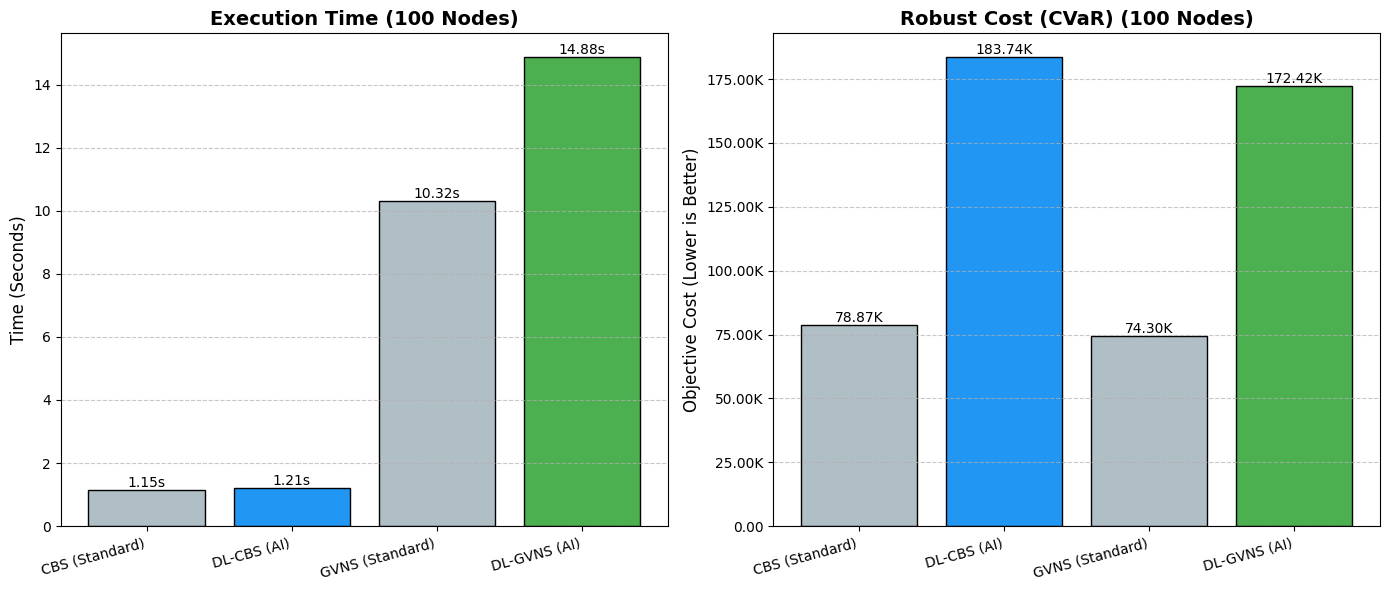


************************************************************
🌟 PROCESSING DATASET: 150 NODES
************************************************************

--- Starting Label Generation Pipeline ---
Target: Generate 200 samples of size 10 nodes.

Generating Sample 1/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [0, 30, 36] | CVaR: 94.22

Generating Sample 2/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [11, 55, 132] | CVaR: 214.82

Generating Sample 3/200...
[✓] Solved in 26.4s | Selected Hubs (Original Indices): [2, 68, 96] | CVaR: 170.81

Generating Sample 4/200...
[✓] Solved in 27.3s | Selected Hubs (Original Indices): [33, 98, 114] | CVaR: 66.54

Generating Sample 5/200...
[✓] Solved in 27.0s | Selected Hubs (Original Indices): [28, 45, 104] | CVaR: 56.95

Generating Sample 6/200...
[✓] Solved in 26.5s | Selected Hubs (Original Indices): [33, 79, 146] | CVaR: 69.10

Generating Sample 7/200...
[✓] Solved in 26.4s | Selected Hubs (Original Indices): 

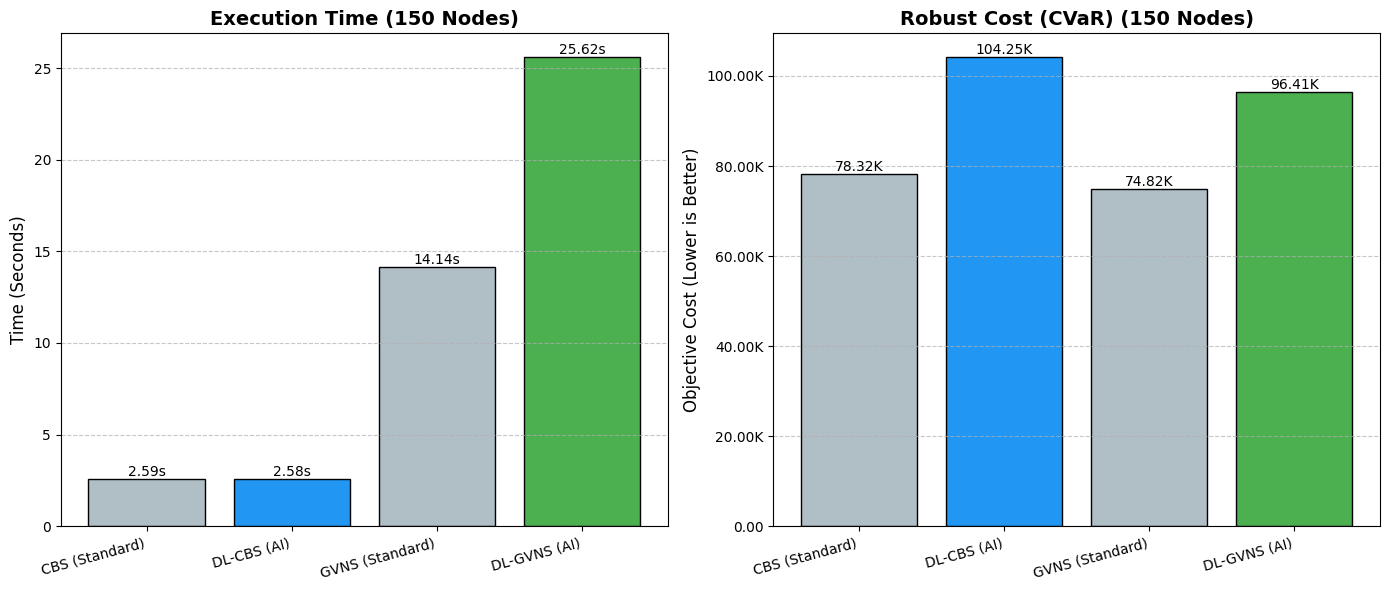


************************************************************
🌟 PROCESSING DATASET: 200 NODES
************************************************************

--- Starting Label Generation Pipeline ---
Target: Generate 200 samples of size 10 nodes.

Generating Sample 1/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [24, 102, 169] | CVaR: 76.85

Generating Sample 2/200...
[✓] Solved in 26.6s | Selected Hubs (Original Indices): [20, 95, 139] | CVaR: 260.94

Generating Sample 3/200...
[✓] Solved in 26.3s | Selected Hubs (Original Indices): [82, 102, 133] | CVaR: 40.50

Generating Sample 4/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [55, 122, 194] | CVaR: 135.76

Generating Sample 5/200...
[✓] Solved in 26.2s | Selected Hubs (Original Indices): [75, 146, 156] | CVaR: 102.48

Generating Sample 6/200...
[✓] Solved in 25.8s | Selected Hubs (Original Indices): [61, 136, 164] | CVaR: 57.23

Generating Sample 7/200...
[✓] Solved in 25.9s | Selected Hubs (Original 

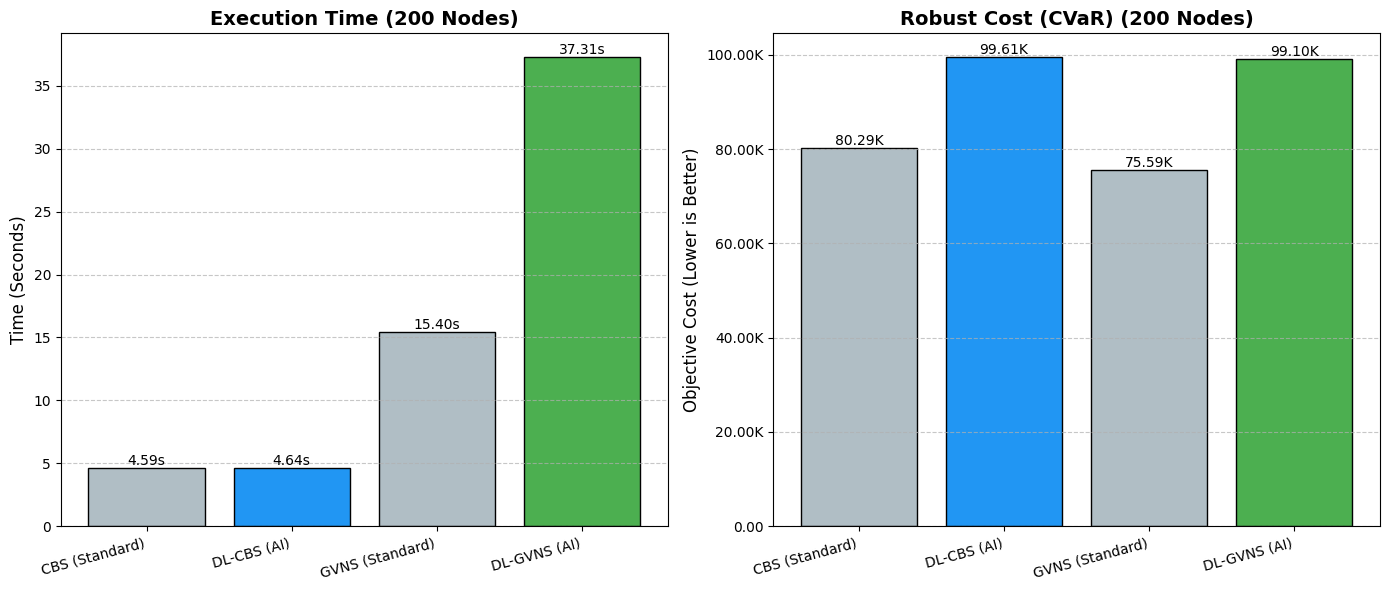


✅ BATCH PIPELINE COMPLETE!
📈 All plots saved as PNG images.
💾 Master data saved to 'All_Datasets_Results.csv'.
    Nodes           Method   Time (s)   Robust Cost
0      25   CBS (Standard)   0.224910  8.592807e+09
1      25      DL-CBS (AI)   0.084179  8.592807e+09
2      25  GVNS (Standard)   0.315784  8.565026e+09
3      25     DL-GVNS (AI)   0.317835  8.565026e+09
4     100   CBS (Standard)   1.153415  7.886828e+04
5     100      DL-CBS (AI)   1.210322  1.837365e+05
6     100  GVNS (Standard)  10.322899  7.429716e+04
7     100     DL-GVNS (AI)  14.879285  1.724235e+05
8     150   CBS (Standard)   2.589331  7.832275e+04
9     150      DL-CBS (AI)   2.576256  1.042546e+05
10    150  GVNS (Standard)  14.140771  7.482061e+04
11    150     DL-GVNS (AI)  25.622494  9.641072e+04
12    200   CBS (Standard)   4.587917  8.029409e+04
13    200      DL-CBS (AI)   4.639190  9.960548e+04
14    200  GVNS (Standard)  15.400283  7.559380e+04
15    200     DL-GVNS (AI)  37.311239  9.910384e+04


In [10]:

def generate_naive_rankings(W_matrix):
    """
    Calculates a naive score for each node based purely on its total raw demand
    (Production + Attraction). This acts as our baseline (non-AI) ranking.
    """
    production = np.sum(W_matrix, axis=1)
    attraction = np.sum(W_matrix, axis=0)
    total_demand = production + attraction
    
    # Normalize to act like a probability score (0 to 1)
    naive_probabilities = total_demand / np.max(total_demand)
    return naive_probabilities

def run_phase10_evaluation(C_matrix, W_matrix, C_ijkm, W_ijs, ai_probs, p=3, n_nodes=25):
    """
    Runs the final evaluation comparing Standard Heuristics vs AI-Augmented Heuristics.
    Returns the metrics to be saved globally.
    """
    print(f"\n📊 EVALUATING HEURISTICS FOR {n_nodes} NODES...")
    
    # Generate baseline (non-AI) rankings
    naive_probs = generate_naive_rankings(W_matrix)
    
    metrics = {
        'Method': ['CBS (Standard)', 'DL-CBS (AI)', 'GVNS (Standard)', 'DL-GVNS (AI)'],
        'Time': [],
        'Cost': []
    }
    
    # ---------------------------------------------------------
    # 1. Standard CBS (Using Naive Demand Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_cbs = dl_cbs_heuristic(
        C_matrix=C_matrix, W_matrix=W_matrix, C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=naive_probs, p=p, candidates_per_cluster=2
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_cbs)
    
    # ---------------------------------------------------------
    # 2. DL-CBS (Using AI Neural Network Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_dl_cbs = dl_cbs_heuristic(
        C_matrix=C_matrix, W_matrix=W_matrix, C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=ai_probs, p=p, candidates_per_cluster=2
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_dl_cbs)
    
    # ---------------------------------------------------------
    # 3. Standard GVNS (Using Naive Demand Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_gvns = dl_gvns_heuristic(
        C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=naive_probs, p=p, max_iters=150
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_gvns)
    
    # ---------------------------------------------------------
    # 4. DL-GVNS (Using AI Neural Network Rankings)
    # ---------------------------------------------------------
    start_t = time.time()
    _, cost_dl_gvns = dl_gvns_heuristic(
        C_ijkm=C_ijkm, W_ijs=W_ijs, 
        probabilities=ai_probs, p=p, max_iters=150
    )
    metrics['Time'].append(time.time() - start_t)
    metrics['Cost'].append(cost_dl_gvns)
    
    # ---------------------------------------------------------
    # PLOTTING THE RESULTS
    # ---------------------------------------------------------
    print(f"\nGenerating and saving comparative plots for {n_nodes} nodes...")
    colors = ['#B0BEC5', '#2196F3', '#B0BEC5', '#4CAF50']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Execution Time
    bars1 = ax1.bar(metrics['Method'], metrics['Time'], color=colors, edgecolor='black')
    ax1.set_title(f'Execution Time ({n_nodes} Nodes)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Time (Seconds)', fontsize=12)
    ax1.set_xticks(range(len(metrics['Method'])))
    ax1.set_xticklabels(metrics['Method'], rotation=15, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}s', ha='center', va='bottom')
        
    # Plot 2: Robust Cost (CVaR)
    bars2 = ax2.bar(metrics['Method'], metrics['Cost'], color=colors, edgecolor='black')
    ax2.set_title(f'Robust Cost (CVaR) ({n_nodes} Nodes)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Objective Cost (Lower is Better)', fontsize=12)
    ax2.set_xticks(range(len(metrics['Method'])))
    ax2.set_xticklabels(metrics['Method'], rotation=15, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # --- DYNAMIC FORMATTER ADDED HERE ---
    def dynamic_formatter(x, pos=None):
        if x >= 1e9:
            return f'{x / 1e9:.2f}B'
        elif x >= 1e6:
            return f'{x / 1e6:.2f}M'
        elif x >= 1e3:
            return f'{x / 1e3:.2f}K'
        else:
            return f'{x:.2f}'
            
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(dynamic_formatter))
    
    for bar in bars2:
        yval = bar.get_height()
        label = dynamic_formatter(yval)
        ax2.text(bar.get_x() + bar.get_width()/2, yval, label, ha='center', va='bottom')
        
    plt.tight_layout()
    
    # Save the plot before showing it
    plt.savefig(f"Evaluation_Plot_{n_nodes}_Nodes.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics


def run_batch_evaluation_pipeline(dataset_folder):
    """
    Loops through every dataset (25, 100, 150, 200 nodes), executes the pipeline,
    and aggregates all metrics into a single CSV file.
    """
    print("="*50)
    print("🚀 STARTING BATCH PIPELINE FOR ALL DATASETS")
    print("="*50)
    
    C_data, W_data = load_all_datasets(dataset_folder)
    all_results = []
    
    # Sort the datasets so we process them from smallest to largest
    for n_nodes in sorted(C_data.keys()):
        if n_nodes not in W_data:
            continue
            
        print(f"\n{'*'*60}")
        print(f"🌟 PROCESSING DATASET: {n_nodes} NODES")
        print(f"{'*'*60}")
        
        C_matrix = C_data[n_nodes]
        W_matrix = W_data[n_nodes]
        
        # 1. Phase 2: Generate Training Labels (We keep subset_size=10 for speed)
        training_labels = generate_training_labels(
            C_matrix=C_matrix, W_matrix=W_matrix, 
            num_samples=200, subset_size=10, p=3, num_scenarios=20
        )
        
        # 2. Phase 3: Train Model specifically for this graph size
        trained_model = train_dlhr_model(
            training_labels=training_labels, C_data=C_matrix, W_data=W_matrix, 
            epochs=150, lr=0.01
        )
        
        # 3. Get AI Predictions
        ranked_nodes, ai_probs = get_dl_rankings(trained_model, C_matrix, W_matrix)
        
        # 4. Generate the full matrices (float32 to prevent memory crashes)
        print(f"\nGenerating full scenarios and path costs for {n_nodes} nodes...")
        W_ijs_full = generate_demand_scenarios(W_matrix, num_scenarios=20).astype(np.float32)
        C_ijkm_full = calculate_path_costs(C_matrix, alpha=0.5).astype(np.float32)
        
        # 5. Run Phase 10 Evaluation
        metrics = run_phase10_evaluation(
            C_matrix=C_matrix, W_matrix=W_matrix, 
            C_ijkm=C_ijkm_full, W_ijs=W_ijs_full, 
            ai_probs=ai_probs, p=3, n_nodes=n_nodes
        )
        
        # 6. Append to our global results
        for i in range(len(metrics['Method'])):
            all_results.append({
                'Nodes': n_nodes,
                'Method': metrics['Method'][i],
                'Time (s)': metrics['Time'][i],
                'Robust Cost': metrics['Cost'][i]
            })
            
        # Free memory before moving to the next dataset (Crucial for 150/200 nodes)
        del W_ijs_full
        del C_ijkm_full
        gc.collect()

    # ---------------------------------------------------------
    # FINAL EXPORT
    # ---------------------------------------------------------
    df_results = pd.DataFrame(all_results)
    df_results.to_csv("All_Datasets_Results.csv", index=False)
    
    print("\n" + "="*50)
    print("✅ BATCH PIPELINE COMPLETE!")
    print("📈 All plots saved as PNG images.")
    print("💾 Master data saved to 'All_Datasets_Results.csv'.")
    print("="*50)
    print(df_results)


if __name__ == "__main__":
    # Point this to your Kaggle dataset folder
    dataset_folder = r"/kaggle/input/datasets/infernalss/node-dataset"
    run_batch_evaluation_pipeline(dataset_folder)